In [158]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [159]:
df = pd.read_csv('../data/samplesuperstore.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [161]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [162]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [ ]:
df["Profit Margin"] = df["Profit"] / df["Sales"]
df["Price per unit"] = df["Sales"] / df["Quantity"]
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Ship Year"] = df["Ship Date"].dt.year
df["Ship Month"] = df["Ship Date"].dt.month

In [ ]:
conn = sqlite3.connect("../database/sales.db")
cursor =  conn.cursor()
df.to_sql("orders", conn, if_exists="replace", index=False)

10194

In [165]:
query = """
CREATE TABLE dim_product AS
SELECT ROW_NUMBER() OVER (ORDER BY "Product ID", "Product Name") AS ProductRowID,
"Product ID",
"Product Name",
Category,
"Sub-Category"
FROM orders
GROUP BY "Product ID", "Product Name", Category, "Sub-Category"
"""
cursor.execute("DROP TABLE IF EXISTS dim_product")
conn.commit()
cursor.execute(query)
conn.commit() ##Product Dimension/lookup

In [166]:
query = """
CREATE TABLE dim_region AS
SELECT ROW_NUMBER() OVER (ORDER BY Region) AS RegionKey, Region
FROM orders
GROUP BY Region
"""
cursor.execute("DROP TABLE IF EXISTS dim_region")
conn.commit()
cursor.execute(query)
conn.commit() ##Region Dimension

In [167]:
query = """
CREATE TABLE dim_date AS
SELECT "Order Date", "Order Year", "Order Month", "Order ID"
FROM orders
GROUP BY "Order Date", "Order Year", "Order Month"
"""
cursor.execute("DROP TABLE IF EXISTS dim_date")
conn.commit()
cursor.execute(query)
conn.commit() ##Date Dimension

In [168]:
query = """
CREATE TABLE fact_sales AS
SELECT o."Row ID", o."Order ID", o."Order Date", p.ProductRowID, r.RegionKey, o.Sales, o.Profit, o.Quantity, o.Discount
FROM orders o
JOIN dim_product p 
ON o."Product ID" = p."Product ID"
AND o."Product Name" = p."Product Name"
JOIN dim_region r
ON o.Region = r.Region
"""
cursor.execute("DROP TABLE IF EXISTS fact_sales")
conn.commit()
cursor.execute(query)
conn.commit()  ##Main analytics table

In [169]:
tables = pd.read_sql("SELECT name from sqlite_master WHERE type='table';", conn)
tables

,name
0,orders
1,dim_product
2,dim_region
3,dim_date
4,fact_sales


In [170]:
query = """
SELECT p."Category", SUM(f.Sales) AS Revenue
FROM fact_sales f
JOIN dim_product p
ON f."ProductRowID" = p."ProductRowID"
GROUP BY p.Category
ORDER BY Revenue DESC
"""
pd.read_sql(query, conn) ##best selling category

,Category,Revenue
0,Technology,839893.2790
1,Furniture,754747.7613
2,Office Supplies,731893.3140


In [171]:
query = """
SELECT p."Product Name", SUM(f.Sales) AS Revenue
FROM fact_sales f
JOIN dim_product p
ON f."ProductRowID" = p."ProductRowID"
GROUP BY p."Product Name"
ORDER BY Revenue DESC
LIMIT 10
"""
pd.read_sql(query, conn) ##top 10 products

,Product Name,Revenue
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


In [172]:
query = """
SELECT "Region", SUM(Sales) as Revenue
FROM orders 
GROUP BY "Region"
ORDER BY SUM(Sales) DESC
"""
pd.read_sql(query, conn) ##Best selling region

,Region,Revenue
0,West,739813.6085
1,East,691828.1680
2,Central,503170.6728
3,South,391721.9050


In [173]:
query = """
SELECT d."Order Year", d."Order Month", SUM(f.Sales) AS Revenue
FROM fact_sales f
JOIN dim_date d
ON f."Order ID" = d."Order ID"
GROUP BY d."Order Year", d."Order Month"
ORDER BY d."Order Year", d."Order Month"
"""

pd.read_sql(query, conn) ##monthly growth

,Order Year,Order Month,Revenue
0,2023,1,10531.4690
1,2023,2,2403.5960
2,2023,3,15880.3800
3,2023,4,15232.5690
4,2023,5,9962.4530
5,2023,6,21163.3086
6,2023,7,20131.5950
7,2023,8,11641.1835
8,2023,9,17697.6308
9,2023,10,12777.4040


In [174]:
query = """
SELECT "Region", SUM(profit) AS Profit
FROM orders 
GROUP BY "Region"
ORDER BY "Profit" DESC
"""
pd.read_sql(query, conn) ##Most profitable region

,Region,Profit
0,West,110798.8170
1,East,94883.2603
2,South,46749.4303
3,Central,39865.3070


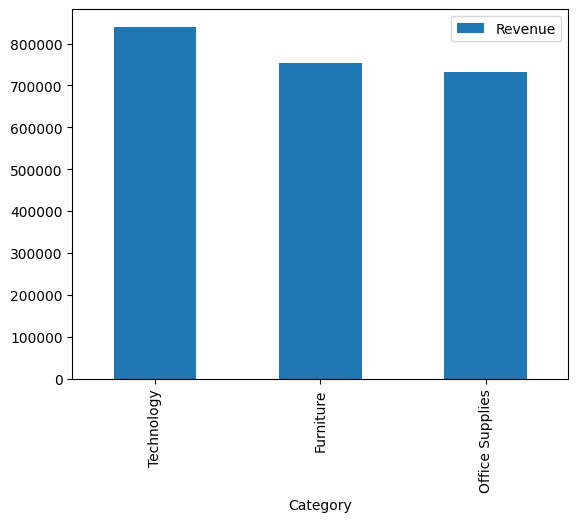

In [175]:
query = """
SELECT p.Category, SUM(f.Sales) AS Revenue
FROM fact_sales f
JOIN dim_product p
ON f."ProductRowID" = p."ProductRowID"
GROUP BY p.Category
ORDER BY Revenue DESC
"""

category_sales = pd.read_sql(query, conn)

category_sales.plot(x="Category", y="Revenue", kind="bar")
plt.show() ##Category Revenue

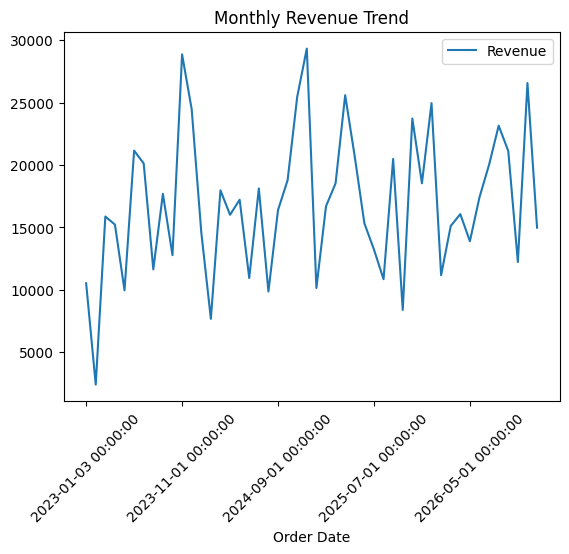

In [176]:
query = """
SELECT 
    d."Order Date",
    d."Order Year",
    d."Order Month",
    SUM(f.Sales) AS Revenue
FROM fact_sales f
JOIN dim_date d
ON f."Order ID" = d."Order ID"
GROUP BY d."Order Year", d."Order Month"
ORDER BY d."Order Year", d."Order Month"
"""

monthly_sales = pd.read_sql(query, conn)
monthly_sales.plot(x="Order Date", y="Revenue")

plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

<Axes: >

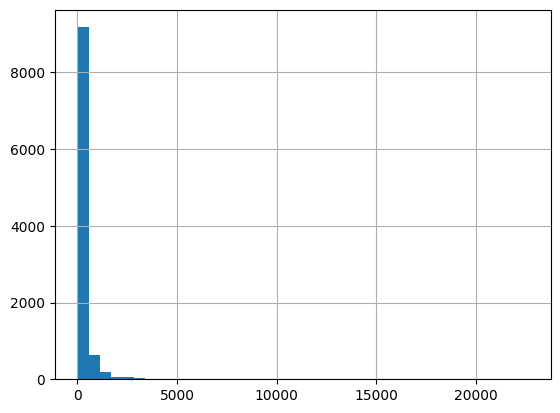

In [177]:
df["Sales"].hist(bins=40) ##Revenue Distribution

In [178]:
df["Sales"].agg(["mean", "median", "std", "skew", "kurtosis"])

mean        228.225854
median       53.910000
std         619.906839
skew         12.983926
kurtosis    306.366270
Name: Sales, dtype: float64

<Axes: >

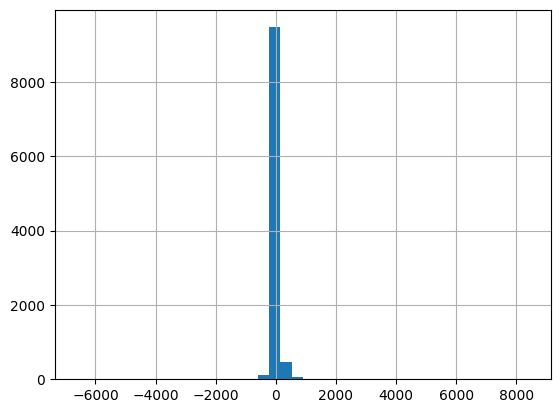

In [179]:
df["Profit"].hist(bins=40) ##Profit Distribution

In [180]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

In [181]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64

In [182]:
#Pareto Principle 80%/20%
top_20_pct = df.sort_values("Sales", ascending=False).head(int(len(df)*.2))
concentration = top_20_pct["Sales"].sum() / df["Sales"].sum()
print(top_20_pct)
print(concentration) ##top 20% contribute this much of total revenue

      Row ID        Order ID Order Date  Ship Date       Ship Mode  \
226      227  US-2023-145317 2023-03-18 2023-03-23  Standard Class   
5894    5895  US-2025-118689 2025-10-02 2025-10-09  Standard Class   
7255    7256  US-2026-140151 2026-03-23 2026-03-25     First Class   
9171    9172  US-2026-127180 2026-10-22 2026-10-24     First Class   
9517    9518  US-2026-166709 2026-11-17 2026-11-22  Standard Class   
...      ...             ...        ...        ...             ...   
5572    5573  US-2025-158099 2025-09-03 2025-09-05     First Class   
4524    4525  US-2025-151827 2025-03-31 2025-04-02    Second Class   
7852    7853  US-2026-140963 2026-06-10 2026-06-13     First Class   
5394    5395  US-2025-136770 2025-08-14 2025-08-18  Standard Class   
1729    1730  US-2023-124730 2023-11-26 2023-11-26        Same Day   

     Customer ID     Customer Name      Segment Country/Region           City  \
226     SM-20320       Sean Miller  Home Office  United States   Jacksonville 

In [183]:
df[["Sales", "Profit", "Quantity", "Discount"]].corr() ##to look at mutlicollinearity

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.481460,0.198457,-0.027756
Profit,0.481460,1.000000,0.066145,-0.218882
Quantity,0.198457,0.066145,1.000000,0.007475
Discount,-0.027756,-0.218882,0.007475,1.000000


In [184]:
categ_eff = df.groupby("Category").agg({"Sales" : "sum", "Profit" : "sum", "Profit Margin" : "mean"})
print(categ_eff) #categorical efficiency

                       Sales       Profit  Profit Margin
Category                                                
Furniture        754747.7613   19729.9956       0.042663
Office Supplies  731893.3140  126023.4434       0.139999
Technology       839893.2790  146543.3756       0.157680


In [185]:
monthly = df.groupby("Order Date")["Sales"].sum()
monthly.rolling(7).mean()

Order Date
2023-01-03            NaN
2023-01-04            NaN
2023-01-05            NaN
2023-01-06            NaN
2023-01-07            NaN
                 ...     
2026-12-26    3091.576000
2026-12-27    3061.992571
2026-12-28    2992.908400
2026-12-29    2373.007400
2026-12-30    2200.155686
Name: Sales, Length: 1242, dtype: float64

In [186]:
Q1 = df["Sales"].quantile(.25)
Q3 = df["Sales"].quantile(.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
statistical_outliers = df[df["Sales"] > upper_bound]
print(f"Number of statistical sales outliers discovered via IQR: {len(statistical_outliers)}")
sales_threshold_high = df["Sales"].quantile(.90)
business_outliers = df[(df["Sales"] >= sales_threshold_high) & (df["Profit"] < 0)]
print(f"Number of 'Business Outliers' (High Sales, Negative Profit): {len(business_outliers)}")
print("\nTop 5 Most Damaging Business Outliers:")
print(business_outliers[["Order ID", "Product Name", "Sales", "Profit", "Discount"]].sort_values(by="Profit").head())
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=.01, random_state=42)
df['is_anomaly'] = iso_forest.fit_predict(df[['Sales', 'Profit', 'Discount']])
multivariate_outliers = df[df['is_anomaly'] == -1]
print(f"\nNumber of multi-dimensional anomalies (Isolation Forest): {len(multivariate_outliers)}")

Number of statistical sales outliers discovered via IQR: 1183
Number of 'Business Outliers' (High Sales, Negative Profit): 215

Top 5 Most Damaging Business Outliers:
            Order ID                               Product Name     Sales  \
6398  US-2025-108196  Cubify CubeX 3D Printer Double Head Print  4499.985   
9318  US-2026-168116  Cubify CubeX 3D Printer Triple Head Print  7999.980   
821   US-2023-169019  GBC DocuBind P400 Electric Binding System  2177.584   
7441  US-2026-134845  Lexmark MX611dhe Monochrome Laser Printer  2549.985   
9845  US-2026-122714       Ibico EPK-21 Electric Binding System  1889.990   

         Profit  Discount  
6398 -6599.9780       0.7  
9318 -3839.9904       0.5  
821  -3701.8928       0.8  
7441 -3399.9800       0.7  
9845 -2929.4845       0.8  

Number of multi-dimensional anomalies (Isolation Forest): 102


In [187]:
##conversion to csv for Power BI
pd.read_sql("SELECT * FROM fact_sales", conn).to_csv("../data/fact_sales.csv", index=False)
pd.read_sql("SELECT * FROM dim_product", conn).to_csv("../data/dim_product.csv", index=False)
pd.read_sql("SELECT * FROM dim_region", conn).to_csv("../data/dim_region.csv", index=False)
pd.read_sql("SELECT * FROM dim_date", conn).to_csv("../data/dim_date.csv", index=False)